In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.decomposition import NMF
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_post = pd.read_csv('../data/oon/df_post_oon.pkl')

In [12]:
post2labels = df_post['Label'].to_dict()

Remove duplicate

In [13]:
seen = set()
post2labels_dd = {}

for key, value in post2labels.items():
    value_tuple = tuple(value)  # Convert list to tuple to make it hashable
    if value_tuple not in seen:
        post2labels_dd[key] = value
        seen.add(value_tuple)

In [ ]:
def create_topic_matrix_nmf(post2labels, use_counts=True, topic_list=None):
    """
    Create topic matrix for NMF
    If use_counts=True, uses topic frequency per post
    If use_counts=False, uses binary presence/absence
    """
    if topic_list is None:
        all_topics = set()
        for topics in post2labels.values():
            all_topics.update(topics)
        topic_list = sorted(list(all_topics))
    
    post_ids = list(post2labels.keys())
    n_posts = len(post_ids)
    n_topics = len(topic_list)
    
    topic_matrix = np.zeros((n_posts, n_topics), dtype=float)
    topic_to_idx = {topic: i for i, topic in enumerate(topic_list)}
    
    for i, post_id in enumerate(post_ids):
        post_topics = post2labels[post_id]
        
        if use_counts:
            # Count frequency of each topic (for repeated topics)
            topic_counts = {}
            for topic in post_topics:
                topic_counts[topic] = topic_counts.get(topic, 0) + 1
            
            for topic, count in topic_counts.items():
                if topic in topic_to_idx:
                    topic_matrix[i, topic_to_idx[topic]] = count
        else:
            # Binary presence/absence
            for topic in set(post_topics):
                if topic in topic_to_idx:
                    topic_matrix[i, topic_to_idx[topic]] = 1
    
    return topic_matrix, topic_list, post_ids

def run_nmf(post2labels, df_post, n_components_range=range(2, 16),
                               random_state=42, max_iter=500, use_counts=True):
    print("Creating topic matrix...")
    topic_matrix, topic_list, post_ids = create_topic_matrix_nmf(
        post2labels, use_counts=use_counts
    )
    
    print(f"Matrix shape: {topic_matrix.shape}")
    print(f"Topics: {len(topic_list)}")
    print(f"Posts: {len(post_ids)}")
    print(f"Sparsity: {(topic_matrix == 0).sum() / topic_matrix.size:.3f}")
    print(f"Using counts: {use_counts}")

    results = {}
    
    for n_components in n_components_range:
        print(f"Testing {n_components} components...")
        
        # Fit NMF
        nmf = NMF(
            n_components=n_components,
            init='nndsvda',  # Better initialization
            random_state=random_state,
            max_iter=max_iter,
            alpha_W=0.01,  # Small regularization
            alpha_H=0.01,
            l1_ratio=0.5
        )
        
        W = nmf.fit_transform(topic_matrix)
        H = nmf.components_
        
        results[n_components] = {
            'model': nmf,
            'W': W,
            'H': H,
        }

    return {
        'results': results,
        'topic_matrix': topic_matrix,
        'topic_list': topic_list,
        'post_ids': post_ids,
    }

In [ ]:
nmf_results = run_nmf(post2labels_dd, df_post, use_counts=True)

Creating topic matrix...
Matrix shape: (4243, 48)
Topics: 48
Posts: 4243
Sparsity: 0.910
Using counts: True


In [ ]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def calculate_nmf_coherence(results, topic_list, post2labels, post_ids, n_components_range):
    """Calculate coherence scores for NMF models"""
    # Prepare texts for coherence calculation
    texts = [[topic for topic in post2labels[post_id]] for post_id in post_ids]
    dictionary = Dictionary(texts)
    
    coherence_scores = {}
    
    for n_components in n_components_range:
        result = results[n_components]
        H = result['H']  # Components × Topics
        
        # Extract top topics for each component
        top_n = 10
        topics = []
        for comp_id in range(n_components):
            topic_weights = H[comp_id, :]
            top_indices = np.argsort(topic_weights)[-top_n:][::-1]
            top_topics = [topic_list[idx] for idx in top_indices]
            topics.append(top_topics)
        
        # Calculate coherence
        cm = CoherenceModel(
            topics=topics,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_scores[n_components] = cm.get_coherence()
    return coherence_scores

n_components_range = list(nmf_results['results'].keys())
coherence_scores = calculate_nmf_coherence(
    nmf_results['results'],
    nmf_results['topic_list'],
    post2labels_dd,
    nmf_results['post_ids'],
    n_components_range
)

In [ ]:
import itertools
cs_nmf = dict(itertools.islice(coherence_scores.items(), 2, 15))
with open("../data/ablation/cs_nmf", "wb") as fp:
    pickle.dump(cs_nmf, fp)

Get the LDA CVs from the other file:

In [ ]:
cs_lda = pd.read_pickle('../data/ablation/cs_lda')

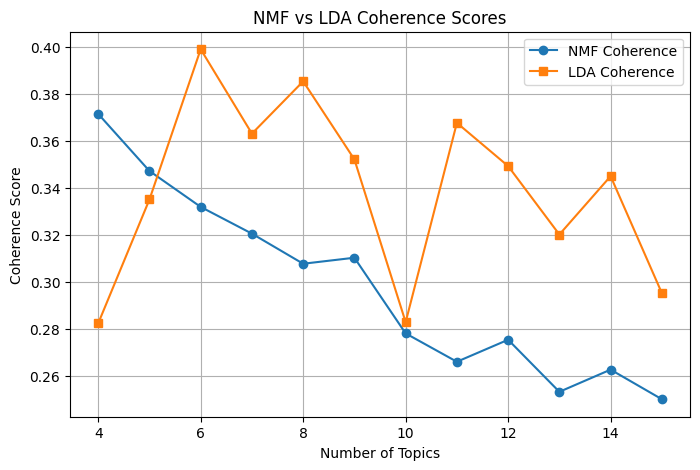

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(cs_nmf.keys()), list(cs_nmf.values()), marker="o", label="NMF Coherence")
plt.plot(list(cs_lda.keys()), list(cs_lda.values()), marker="s", label="LDA Coherence")

plt.title("NMF vs LDA Coherence Scores")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.legend()
plt.grid(True)
plt.show()
